In [145]:
# we import all the necesarry libraries 
import pandas as pd
import numpy as np

In [146]:
#now i have loaded my data
data=pd.read_csv("iris.data")

In [147]:
#i am seeing my first five elements of the data
data.head()

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


In [148]:
#i am seeing random 5 elements from my data
data.sample(5)

,5.1,3.5,1.4,0.2,Iris-setosa
29,4.8,3.1,1.6,0.2,Iris-setosa
105,4.9,2.5,4.5,1.7,Iris-virginica
10,4.8,3.4,1.6,0.2,Iris-setosa
49,7.0,3.2,4.7,1.4,Iris-versicolor
3,5.0,3.6,1.4,0.2,Iris-setosa


In [149]:
# now i am inserting column names in my data
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('iris.data', header=None, names=column_names)

In [150]:
# showing my data
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [151]:
#import sklearn for converting categorical data into numerical data
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to the 'species' column
df['species_encoded'] = label_encoder.fit_transform(df['species'])

# Drop the original 'species' column
df.drop('species', axis=1, inplace=True)

df


,sepal_length,sepal_width,petal_length,petal_width,species_encoded
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# i have change the iris-flower name into 0 , 1 and 2 ....
here Iris-setosa --> 0
Iris-versicolor ---> 1
Iris-virginica ---->2

In [152]:
# Check for null values in each column
null_values = df.isnull().sum()

# Display the result
print(null_values)

sepal_length       0
sepal_width        0
petal_length       0
petal_width        0
species_encoded    0
dtype: int64


# so here we can see that there is no null values in any of the features in my data.

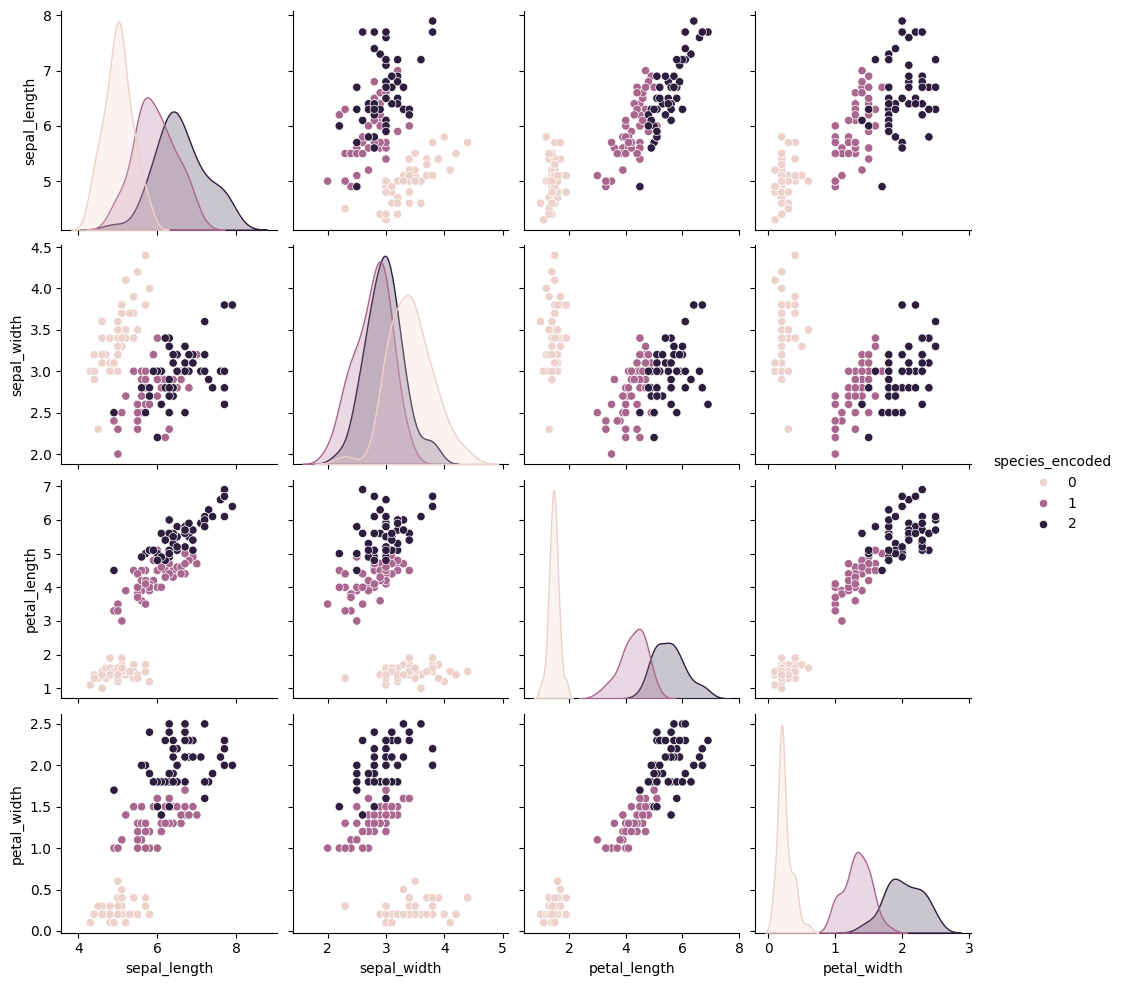

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot to visualize relationships between features and species
sns.pairplot(df, hue='species_encoded')
plt.show()


The pair plot provides a comprehensive visualization of the relationships between the features in the dataset. It shows scatter plots for feature pairs, giving an idea of how they correlate with each other. The diagonal elements display the distribution of individual features through histograms. For instance, we observe that sepal_length and sepal_width seem to have a relatively weak correlation, while petal_length and petal_width demonstrate a stronger linear relationship. The color coding highlights the species, helping identify distinct clusters for each species.

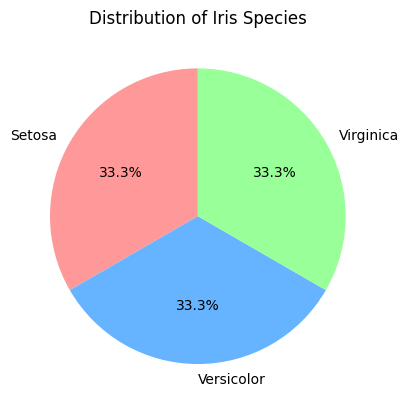

In [154]:
species_counts = df['species_encoded'].value_counts()  # Count the occurrences of each species
species_labels = ['Setosa', 'Versicolor', 'Virginica']
# Create the pie chart
plt.pie(species_counts, labels=species_labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Iris Species')
plt.show()

# By looking at the pie chart, we can understand the relative proportion of each species in the dataset. Here all species have nearly equal distribution, we may conclude that the dataset is well-balanced. If one species is over-represented, it might affect the model's performance and accuracy, and we could consider techniques like data resampling.

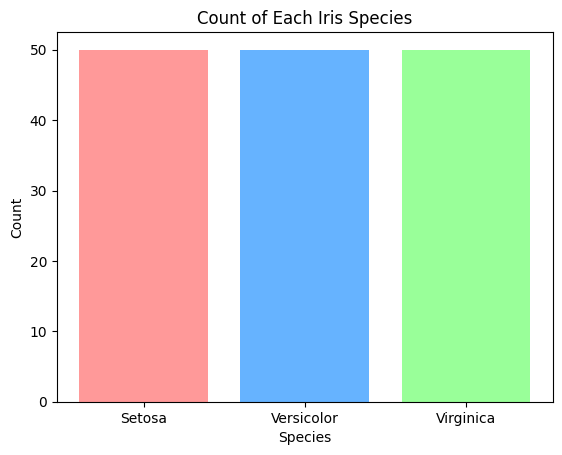

In [155]:
#Here we make bar chart to demonstrate the distribution of scecies_label with their counts 
species_counts = df['species_encoded'].value_counts()
species_labels = ['Setosa', 'Versicolor', 'Virginica']  #keeping this to make sure this cell doesn't need any other cell to run
plt.bar(species_labels, species_counts, color=['#ff9999', '#66b3ff', '#99ff99'])  #bar plot

plt.xlabel('Species')  #x label
plt.ylabel('Count') #y label
plt.title('Count of Each Iris Species') #title
plt.show()

# The bar chart allows for quick identification of the dominant species in the dataset and shows how evenly distributed the species are. This can be useful in understanding the balance of our dataset for classification tasks. Here we can see the equal distribution . If one species has significantly more samples, we may consider addressing imbalance issues (biasing like thing).

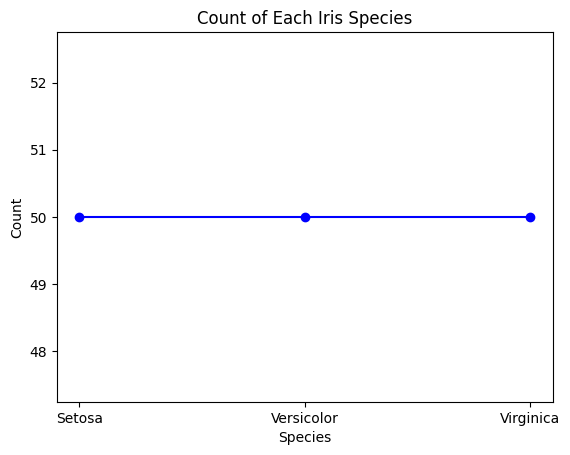

In [156]:
species_counts = df['species_encoded'].value_counts().sort_index()
species_labels = ['Setosa', 'Versicolor', 'Virginica']
plt.plot(species_labels, species_counts, marker='o', linestyle='-', color='b')   # Create the line chart
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Count of Each Iris Species')
plt.show()

# The line chart visually represents the distribution of species in our dataset, with markers indicating the count of each species. Here we see almost straight line because the data distribution is very symmetric. However, as this is categorical data, a line chart might not be as informative as a bar chart or pie chart for visualizing distribution.

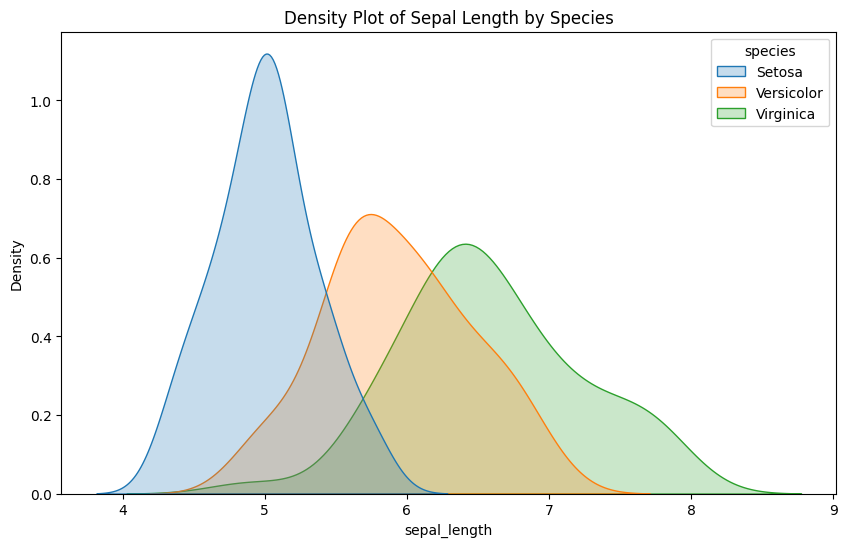

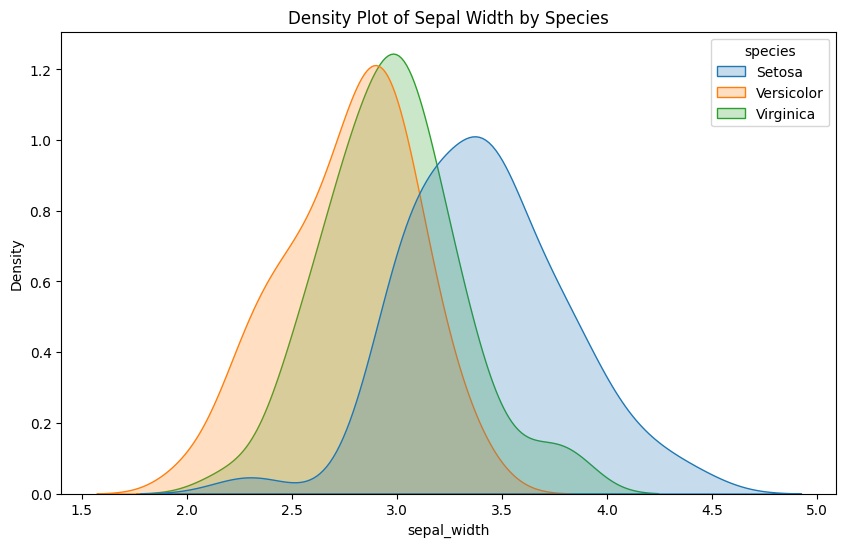

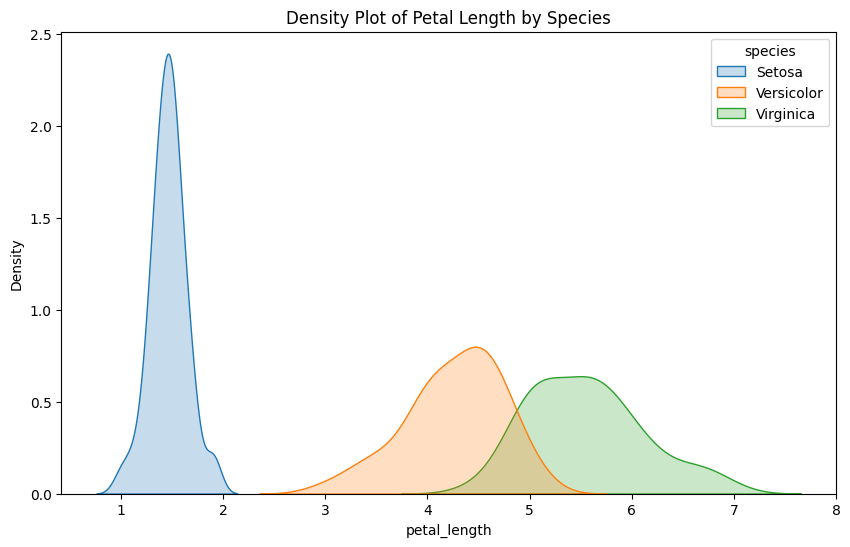

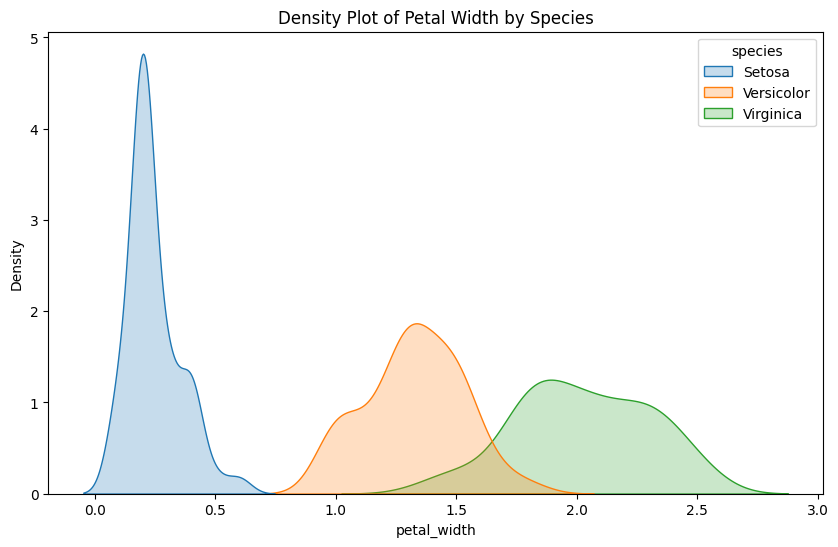

In [157]:
df['species'] = df['species_encoded'].replace({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})  # Define species labels

# Creating density plots for sepal_length, sepal_width, petal_length, and petal_width
plt.figure(figsize=(10, 6))

# Plot for sepal_length
sns.kdeplot(data=df, x='sepal_length', hue='species', fill=True, common_norm=False)
plt.title('Density Plot of Sepal Length by Species')
plt.show()

# Plot for sepal_width
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='sepal_width', hue='species', fill=True, common_norm=False)
plt.title('Density Plot of Sepal Width by Species')
plt.show()

# Plot for petal_length
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='petal_length', hue='species', fill=True, common_norm=False)
plt.title('Density Plot of Petal Length by Species')
plt.show()

# Plot for petal_width
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='petal_width', hue='species', fill=True, common_norm=False)
plt.title('Density Plot of Petal Width by Species')
plt.show()

# Sepal Length and Width: These plots will show the distribution of sepal measurements for each species. Here we may notice that Setosa has shorter sepals compared to all others.
# Petal Length and Width: Similarly, the density plot will visualize the distribution of petal measurements. Setosa may have shorter petals compared to the other two species.
# The area under the curve indicates the relative density of data points. By comparing the shapes of the distributions, we can determine which species tend to have larger or smaller sepal/petal measurements.

/tmp/ipykernel_10219/3508204048.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='species_encoded', y=feature, data=df, ci='sd')


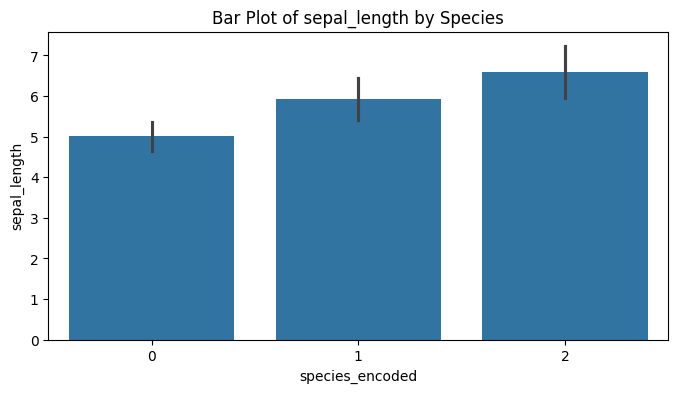

/tmp/ipykernel_10219/3508204048.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='species_encoded', y=feature, data=df, ci='sd')


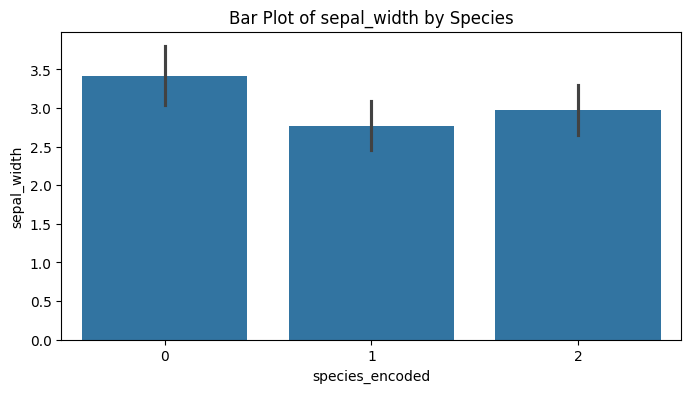

/tmp/ipykernel_10219/3508204048.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='species_encoded', y=feature, data=df, ci='sd')


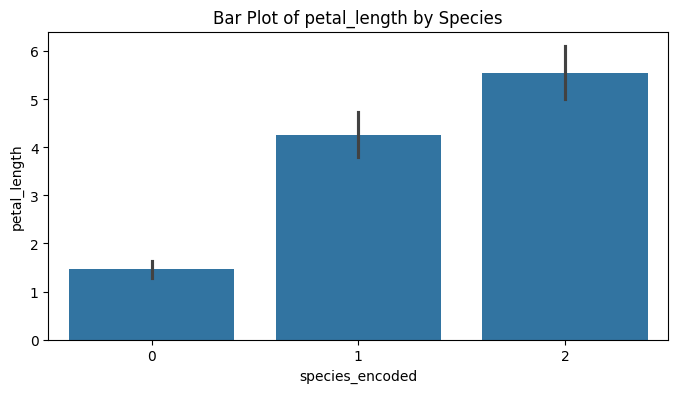

/tmp/ipykernel_10219/3508204048.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='species_encoded', y=feature, data=df, ci='sd')


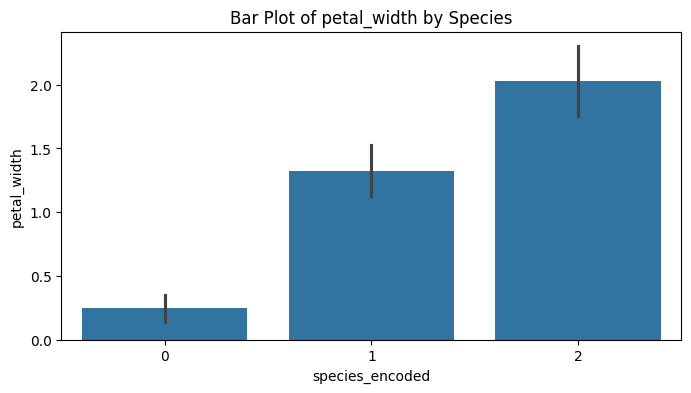

In [158]:
# plotting bar plot
for feature in df.columns[:-2]:  # Skipping the encoded target column
    plt.figure(figsize=(8, 4))
    sns.barplot(x='species_encoded', y=feature, data=df, ci='sd')
    plt.title(f'Bar Plot of {feature} by Species')
    plt.show()


In [159]:
df.drop("species", axis=1, inplace=True)   # dropping the species column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length     150 non-null    float64
 1   sepal_width      150 non-null    float64
 2   petal_length     150 non-null    float64
 3   petal_width      150 non-null    float64
 4   species_encoded  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [160]:
correlation_matrix = df.corr()   # Calculate the correlation matrix
# Display correlation of each feature with the target variable ('species_encoded')
target_correlation = correlation_matrix['species_encoded'].sort_values(ascending=False)
print(target_correlation)

# hello


species_encoded    1.000000
petal_width        0.956464
petal_length       0.949043
sepal_length       0.782561
sepal_width       -0.419446
Name: species_encoded, dtype: float64


#from this correlation matrix we can understand that all the variables have highly correlated with specie_encoded
#now we can see the heatmap 

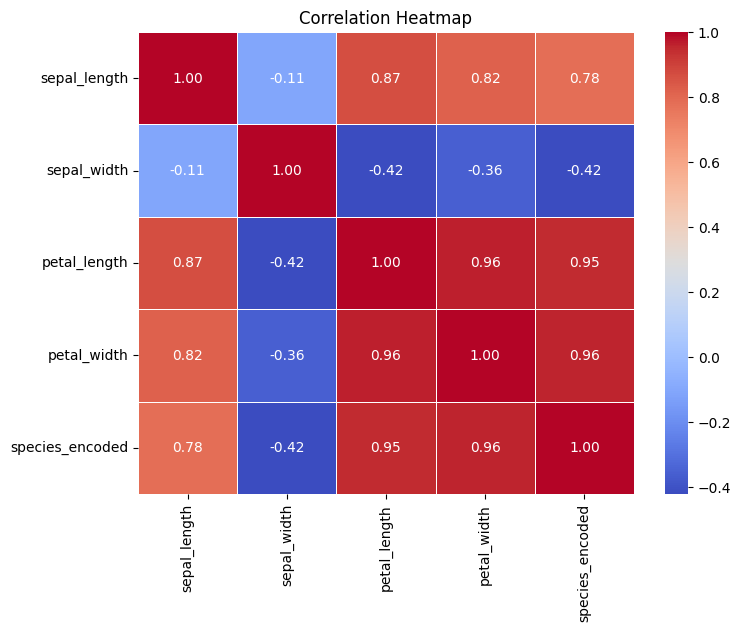

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
# df2 =df
# df2.drop('species_encoded', axis=1, inplace=True)
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


#this is the heatmap of correlation matrix here red colour denote the highly correlated feature and light blue denote the less correlated feature and highly blue denote the very less correlated feature.

In [ ]:
#showing  the data
df

,sepal_length,sepal_width,petal_length,petal_width,species_encoded
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [163]:
#showing the description of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length     150 non-null    float64
 1   sepal_width      150 non-null    float64
 2   petal_length     150 non-null    float64
 3   petal_width      150 non-null    float64
 4   species_encoded  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


#We have done all these so that we can visualize the dataset , now we can see that all the features are important , hence we cannot drop any feature and also by using labelencoder i have change the specie column to specie_encoder so that we can easily find out how much all the feature correlate with this .

In [164]:
#here in x variable i an inserting all the features other than target variable , and in y variable i am inserting the target variable
x = df.iloc[:, 0:3]
y=  df.iloc[:,4:]


In [165]:
x.head()

,sepal_length,sepal_width,petal_length
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


In [166]:
y.head()

,species_encoded
0,0
1,0
2,0
3,0
4,0


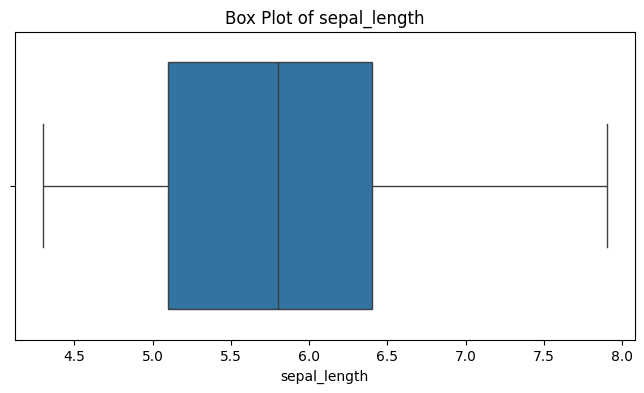

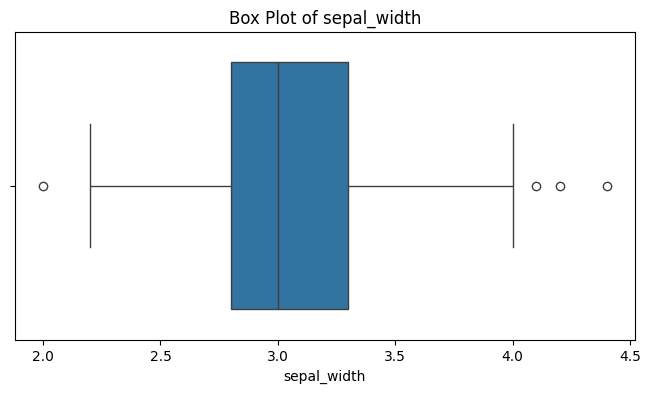

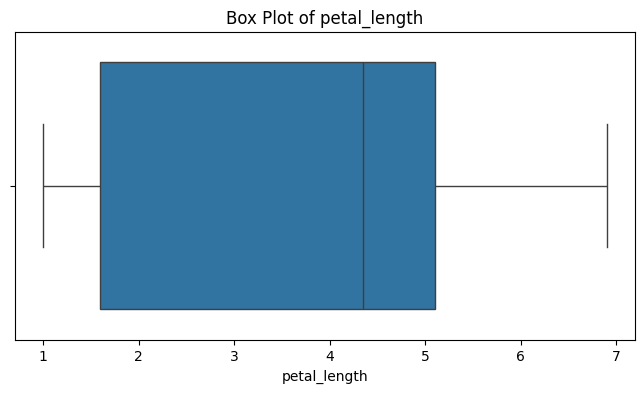

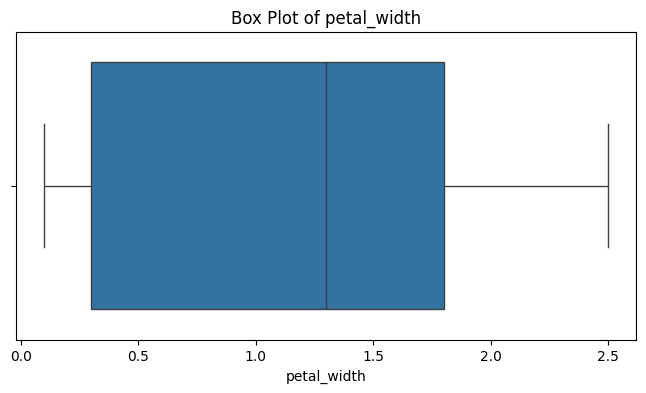

In [167]:
#here i am trying to find if there is any outlier
import matplotlib.pyplot as plt
import seaborn as sns

# For each feature
for feature in df.columns[:-1]:  # Assuming the last column is the target
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

# we are getting four outliers in sepal-width

In [168]:
#now i am going to remove these outliers from my data
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['sepal_width'].quantile(0.25)
Q3 = df['sepal_width'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

# Filter the data, removing outliers in 'sepal_width'
df_filtered = df[(df['sepal_width'] >= lb) & (df['sepal_width'] <= ub)]

# Check the new dataset shape
print("Original DataFrame shape:", df.shape)
print("Filtered DataFrame shape:", df_filtered.shape)

Original DataFrame shape: (150, 5)
Filtered DataFrame shape: (146, 5)


# Q1 (25th percentile): The value below which 25% of the data lies.
# Q3 (75th percentile): The value below which 75% of the data lies.
# The IQR is the range between the 25th and 75th percentiles. It represents the middle 50% of the data.
# Outliers are typically defined as values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR. This is a rule for identifying outliers using the IQR method
 # then i have just filtered out the data by using this part of code[ df_filtered = df[(df['sepal_width'] >= lower_bound) & (df['sepal_width'] <= upper_bound)]]

# we can see that here 4 outliers are removed hence my rows are firstly 150 now it become 146 

In [169]:
#here i am importing my important lbraries for prediction model
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [170]:
# Assuming 'species_encoded' is the target variable
x = df_filtered[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df_filtered['species_encoded']

# here in x variable i am storing all the features except species_encoded , i am doing this because we have to train only these features and apply model on this features to check with y variable means target variable

In [171]:
# i am here going to use the stratified k-cross validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# actually i am not going to make the partition in the model like 80% and 20% , so that i can train 80% data and check on 20% data , here i a using stratified cross validation technique in this i have give the n_splits=10 means it make approx 10 sets 15 element and in each iteration this 15 data are change every time and find accuracy for each iterration then we calculate mean of these accuracies

In [172]:
# Create a pipeline that first scales the data, then fits the model
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Perform cross-validation
scores = cross_val_score(model, x, y, cv=skf, scoring='accuracy')

print("Mean accuracy:", scores.mean()*100)

Mean accuracy: 95.14285714285714


I have created a pipeline for procedural work. First, I applied the StandardScaler, but for my data, scaling is not necessary because the ranges of values for different features are not significantly different. Then, I used logistic regression with a maximum of 1000 iterations, which means that the optimization algorithm can take up to 1000 iterations to converge while fitting the logistic regression model. If convergence is not reached within 1000 iterations, it will stop and may raise a warning. After that, I used cross_val_score, which finds the score for each iteration by training on 135 data points and testing on 15 data points. This process shifts in each iteration, and finally, I calculated the mean of all these scores, resulting in an overall score of 95.3 percent.

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Fitting the model
model.fit(x, y)

def predict_species(sepal_length, sepal_width, petal_length, petal_width):
    user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])      # Creating array
    prediction = model.predict(user_input)     # predicting    
    return prediction[0]

# Example usage:
# Input the data in one line using a tuple
features = (6.9,3.1,5.1,2.3)
predicted_species = predict_species(*features)  # Predict species using the tuple 
# Check which species it corresponds to
if predicted_species == 0:
    print("Iris-setosa")
elif predicted_species == 1:
    print("Iris-versicolor")
else:
    print("Iris-virginica")

Iris-virginica


I am making this call for you all to test my model. Please provide the values for sepal_length, sepal_width, petal_length, and petal_width, and it will give you the predicted flower name. Make sure that the values are in float format and within the specified range, as I have scaled the data using the standard formula: (value - min) / (max - min).

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from sklearn.exceptions import ConvergenceWarning
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress general UserWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)  # Suppress runtime warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # Suppress ConvergenceWarnings

# 'df' is our DataFrame and 'species_encoded' is the target variable
x = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_encoded']

# Scaling the data for models that are sensitive to feature scaling
scaler = StandardScaler()
x = scaler.fit_transform(x)

# Define models and their respective hyperparameter grids
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [200, 500, 1000]  # Increased max_iter
    },
    'KNeighborsClassifier': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'DecisionTreeClassifier': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'degree': [2, 3, 4]
    },
    'GaussianNB': {},  # Naive Bayes
    'LinearDiscriminantAnalysis': {},
    'QuadraticDiscriminantAnalysis': {}
}

# Initializing dictionary to store metrics
metrics = {
    'Model': [],
    'Best Parameters': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'Specificity': [],
    'F1 Score': []
}

# Stratified K-fold cross-validation setup
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Loop through each model
for model_name, param_grid in param_grids.items():
    # Get the model class dynamically
    model_class = globals()[model_name]
    if not param_grid:
        # Train the model with default parameters
        model = model_class()  # Instantiate model
        model.fit(x, y)
        y_pred = cross_val_predict(model, x, y, cv=skf)
        best_params = "Default Parameters"
    else:
        # Perform GridSearchCV for hyperparameter tuning
        model = model_class()  # Instantiate model
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            cv=skf,
            verbose=0,  # Suppress output
            n_jobs=-1
        )
        grid_search.fit(x, y)
        y_pred = cross_val_predict(grid_search.best_estimator_, x, y, cv=skf)
        best_params = grid_search.best_params_

    # Generate classification metrics
    report = classification_report(y, y_pred, output_dict=True)
    cm = confusion_matrix(y, y_pred)

    # Calculate specificity for each class
    specificity = []
    for i in range(cm.shape[0]):
        TN = np.sum(np.delete(cm[i], i))
        FP = np.sum(cm[:, i]) - cm[i, i]
        if (TN + FP) == 0:
            specificity.append(np.nan)
        else:
            specificity.append(TN / (TN + FP) * 100)

    avg_specificity = np.nanmean(specificity)

    # Storing metrics for the model
    metrics['Model'].append(model_name)
    metrics['Best Parameters'].append(best_params)
    metrics['Accuracy'].append(report['accuracy'] * 100)
    metrics['Precision'].append(report['weighted avg']['precision'] * 100)
    metrics['Recall'].append(report['weighted avg']['recall'] * 100)
    metrics['Specificity'].append(avg_specificity)
    metrics['F1 Score'].append(report['weighted avg']['f1-score'] * 100)

# Add ANN (Artificial Neural Network) evaluation
def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y)), activation='softmax'))  # Output layer for classification
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

ann = build_ann(x.shape[1])
ann.fit(x, y, epochs=50, verbose=0, batch_size=16)  # Train ANN
y_pred_ann = np.argmax(ann.predict(x), axis=1)  # Predict classes
report_ann = classification_report(y, y_pred_ann, output_dict=True)
metrics['Model'].append("Artificial Neural Network (ANN)")
metrics['Best Parameters'].append("Custom Parameters")
metrics['Accuracy'].append(report_ann['accuracy'] * 100)
metrics['Precision'].append(report_ann['weighted avg']['precision'] * 100)
metrics['Recall'].append(report_ann['weighted avg']['recall'] * 100)
metrics['Specificity'].append("N/A")  # Specificity calculation for ANN is not standard
metrics['F1 Score'].append(report_ann['weighted avg']['f1-score'] * 100)

# Convert metrics dictionary to a pandas DataFrame
metrics_df = pd.DataFrame(metrics)

# Display the results
metrics_df


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x70fc1c74cca0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


,Model,Best Parameters,Accuracy,Precision,Recall,Specificity,F1 Score
0,LogisticRegression,"{'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}",96.666667,96.775057,96.666667,50.0,96.663664
1,KNeighborsClassifier,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",96.666667,96.678671,96.666667,50.0,96.666333
2,DecisionTreeClassifier,"{'criterion': 'entropy', 'max_depth': 30, 'min...",96.000000,96.000000,96.000000,50.0,96.000000
3,SVC,"{'C': 100, 'degree': 2, 'gamma': 'scale', 'ker...",97.333333,97.333333,97.333333,50.0,97.333333
4,GaussianNB,Default Parameters,95.333333,95.344805,95.333333,50.0,95.332867
5,LinearDiscriminantAnalysis,Default Parameters,97.333333,97.333333,97.333333,50.0,97.333333
6,QuadraticDiscriminantAnalysis,Default Parameters,97.333333,97.382479,97.333333,50.0,97.332266
7,Artificial Neural Network (ANN),Custom Parameters,98.000000,98.012538,98.000000,N/A,97.999800


# Here we can see that QDA and ANN get the highest f1 score and accuracy . we can use this to make our report.

In [175]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay
import numpy as np


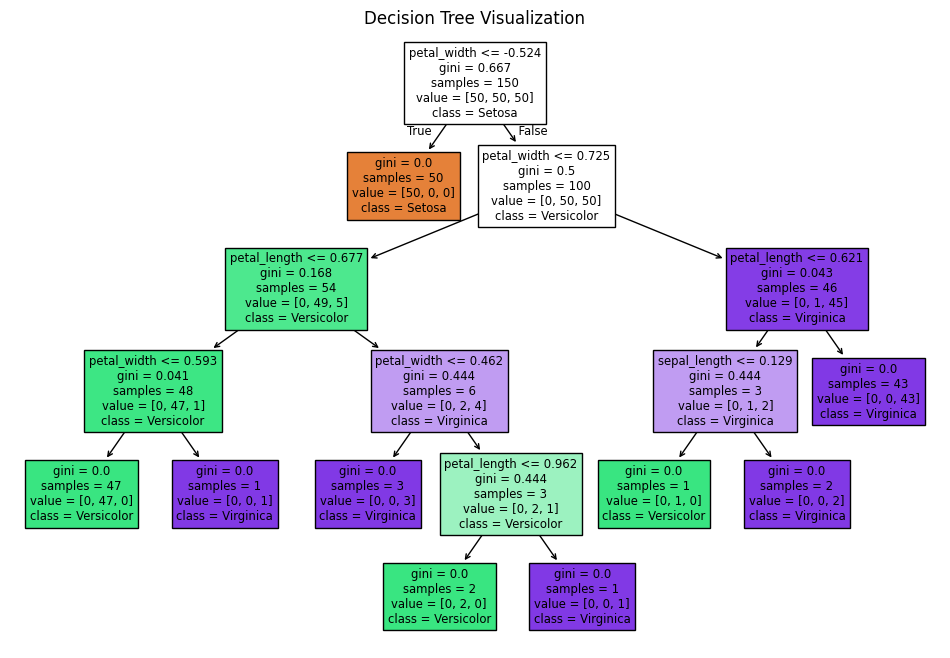

In [ ]:
# feature names
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Scaling data again
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)  # Scaled version for modeling

# Fit a Decision Tree Classifier for visualization
dt_model = DecisionTreeClassifier()
dt_model.fit(x_scaled, y)  # Train on scaled data

# Visualizing the Decision Tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,  # Use original feature names
    class_names=['Setosa', 'Versicolor', 'Virginica'],  # Update with class names as required
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()


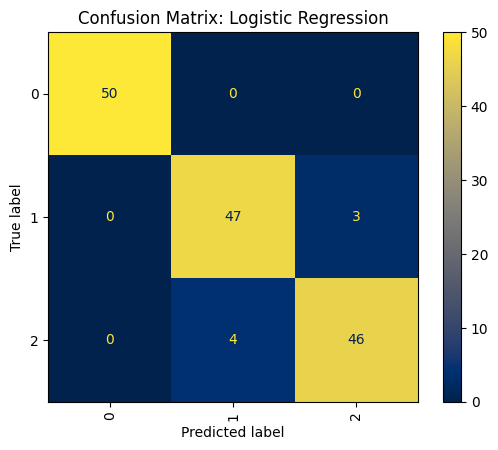

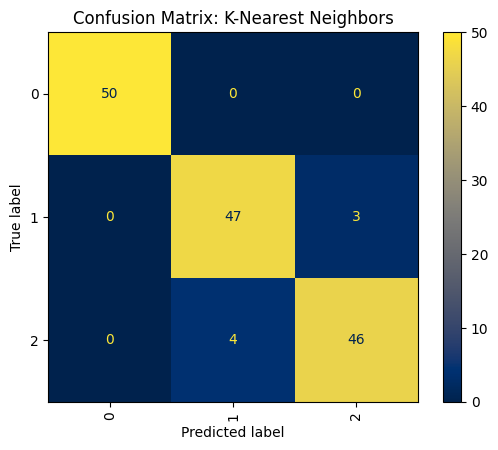

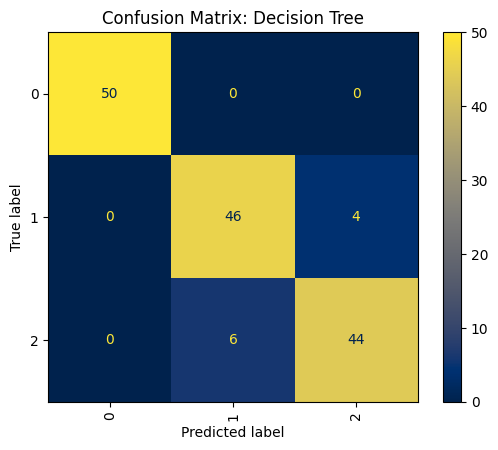

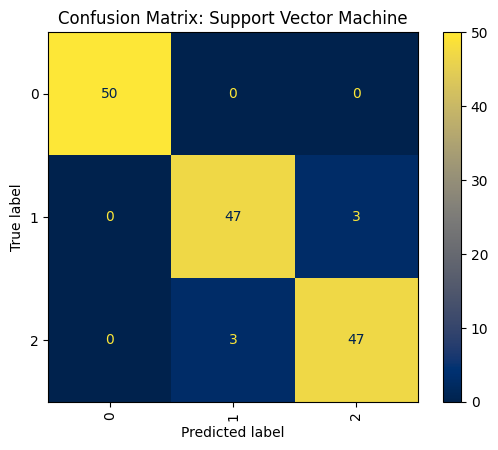

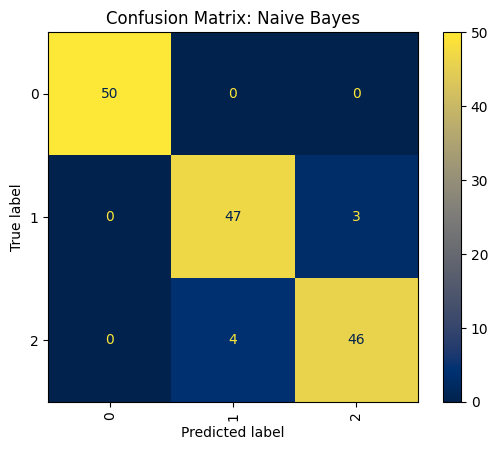

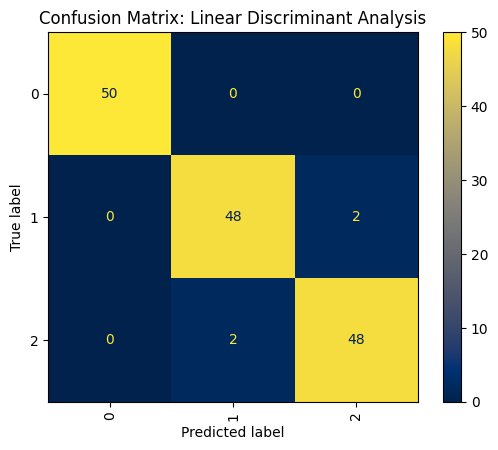

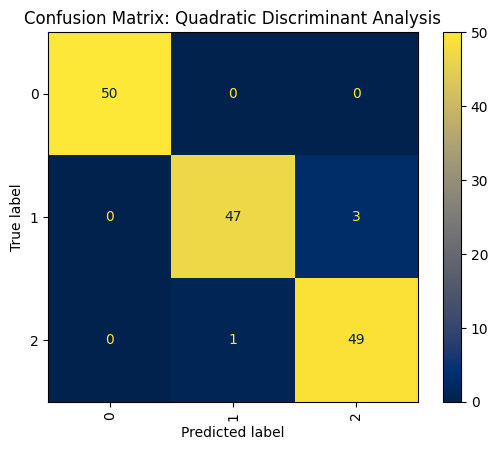

In [179]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure models dictionary is populated and compatible with cross_val_predict
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'Quadratic Discriminant Analysis': QuadraticDiscriminantAnalysis(),
}

# Plot confusion matrix for each model
for model_name, model in models.items():
    y_pred = cross_val_predict(model, x, y, cv=skf)     # Perform cross-validated predictions    
    cm = confusion_matrix(y, y_pred)      # Compute confusion matrix
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))      # Display the confusion matrix
    disp.plot(cmap='cividis', xticks_rotation='vertical')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()


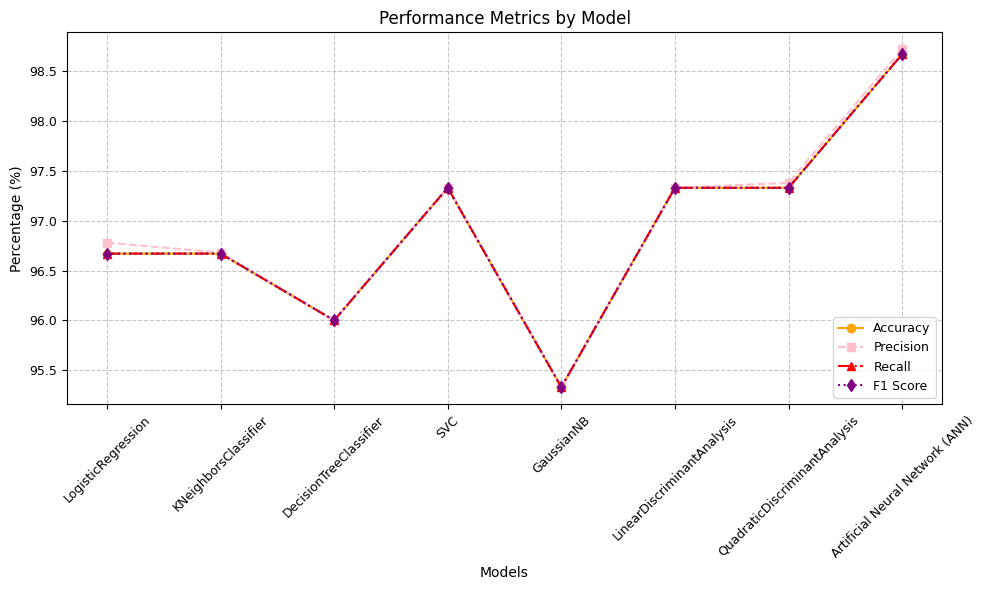

In [ ]:
import matplotlib.pyplot as plt

# Data for the graph
models = [
    "LogisticRegression", "KNeighborsClassifier", "DecisionTreeClassifier", 
    "SVC", "GaussianNB", "LinearDiscriminantAnalysis", 
    "QuadraticDiscriminantAnalysis", "Artificial Neural Network (ANN)"
]
accuracy = [96.67, 96.67, 96.00, 97.33, 95.33, 97.33, 97.33, 98.67]
precision = [96.78, 96.68, 96.00, 97.33, 95.34, 97.33, 97.38, 98.72]
recall = [96.67, 96.67, 96.00, 97.33, 95.33, 97.33, 97.33, 98.67]
f1_score = [96.67, 96.67, 96.00, 97.33, 95.33, 97.33, 97.33, 98.67]

# Plot each metric
plt.figure(figsize=(10, 6))
plt.plot(models, accuracy, label="Accuracy", marker='o', linestyle='-', color='orange')
plt.plot(models, precision, label="Precision", marker='s', linestyle='--', color='pink')
plt.plot(models, recall, label="Recall", marker='^', linestyle='-.', color='red')
plt.plot(models, f1_score, label="F1 Score", marker='d', linestyle=':', color='purple')

# Add labels, title, legend, and grid
plt.xlabel("Models")
plt.ylabel("Percentage (%)")
plt.title("Performance Metrics by Model")
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.legend(loc="lower right", fontsize=9)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
